# Explore change data

In [1]:
import psycopg2
from dotenv import load_dotenv
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

dotenv_path = Path().resolve().parent.parent / ".env"
load_dotenv(dotenv_path, override=True)

DB_USER = os.environ.get("DB_USER")
DB_PASS = os.environ.get("DB_PASS")
DB_NAME = os.environ.get("DB_NAME")
DB_HOST = os.environ.get("DB_HOST")
DB_PORT = os.environ.get("DB_PORT")

conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASS,
    host=DB_HOST,
    port=DB_PORT
)

postgres


In [8]:
def query_to_df(query, connection):
    try:
        with connection.cursor() as cur:
            cur.execute(query)
            
            if cur.description is not None:
                # Get column names
                colnames = [desc[0] for desc in cur.description]
                # Fetch all rows
                rows = cur.fetchall()
                # Return as Pandas DataFrame
                return pd.DataFrame(rows, columns=colnames)
            else:
                print('Query did not return any rows')
                return pd.DataFrame()
    except Exception as e:
        raise e

In [12]:
# number of processed files
df = query_to_df("""
    SELECT COUNT(DISTINCT file_path) as count_files
    FROM revision
    """, conn)
print('Number of processed files: ', df.iloc[0]['count_files'])

# number of entities
df = query_to_df("""
    SELECT COUNT(entity_id) as count_entities
    FROM revision""", conn)
print('Number of entities: ', df.loc[0,'count_entities'])

Number of processed files:  15
Number of entities:  1126710


### Number of revisions over time

/var/folders/py/1mtvyf855ns3_cggxlvpv2hh0000gn/T/ipykernel_42691/1874037746.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["date"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()


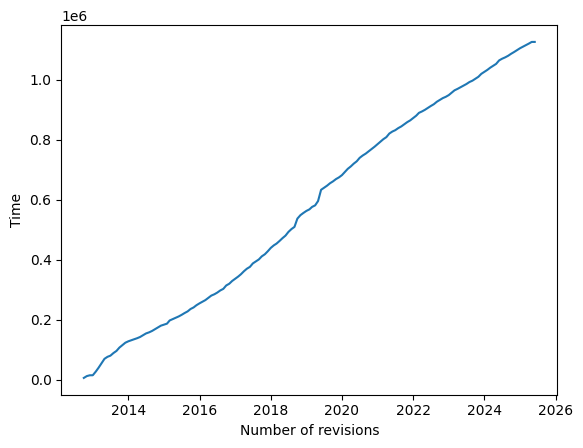

In [13]:
df = query_to_df("""
    SELECT revision_id, entity_id, timestamp
    FROM revision""", conn)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["date"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()

revisions_per_period = (
    df.groupby("date")[["revision_id", "entity_id"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
)

cumulative_revisions = revisions_per_period.cumsum()

plt.plot(cumulative_revisions)
plt.ylabel('Time')
plt.xlabel('Number of revisions')
plt.show()


### Number of created entities over time

In [ ]:
df = query_to_df("""
    SELECT entity_id, timestamp
    FROM revision r JOIN change c on r.revision_id = c.revision_id -- uses FK for join
    WHERE c.target = 'ENTITY' AND c.action = 'CREATE' """, conn)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["date"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()

created_entities_per_period = (
    df.groupby("date")["entity_id"]
    .nunique()
    .reset_index(name="count_entities")
)

plt.plot(
    created_entities_per_period["date"],
    created_entities_per_period["count_entities"],
    marker="o"
)
plt.ylabel('Time')
plt.xlabel('Number of created entities over time')
plt.show()

In [ ]:
change_classification = query_to_df("""
SELECT old_value, new_value, is_vandalism, likely_formatting, likely_typo, likely_value_refinement
FROM change
WHERE likely_formatting IS TRUE OR likely_typo IS TRUE OR likely_value_refinement IS TRUE
LIMIT 1000
""", conn)


In [ ]:
conn.close()